In [1]:
import numpy as np
import pylab
import matplotlib
import matplotlib.pyplot as plt
import os
import matplotlib.cm as cm

In [2]:
params = {'text.usetex': True}
pylab.rcParams.update(params)
FS = 22
matplotlib.rcParams['figure.figsize'] = (10., 10./1.618)
matplotlib.rcParams['figure.titlesize'] = FS
matplotlib.rcParams['figure.subplot.wspace'] = 0.
matplotlib.rcParams['figure.subplot.hspace'] = 0.2
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['font.serif'] = 'Computer Modern Roman'
matplotlib.rcParams['xtick.labelsize'] = FS
matplotlib.rcParams['ytick.labelsize'] = FS
matplotlib.rcParams['axes.labelsize'] = FS
matplotlib.rcParams['legend.fontsize'] = FS
matplotlib.rcParams['legend.borderpad'] = 0.1
matplotlib.rcParams['legend.loc'] = 'best'
matplotlib.rcParams['legend.borderaxespad'] = 0.2
matplotlib.rcParams['legend.fancybox'] = True
matplotlib.rcParams['axes.titlesize'] = FS

In [10]:
files = os.listdir('./')
files = [f for f in files if f.__contains__('sequence.txt')]
labels = [f.split('_')[0] for f in files]



In [4]:
#Const. from Wikipedia
G = 6.67408*1e-11
c = 299792458.
Msun = 1.989*1e30
GMsun_c2 = G*Msun/c**2

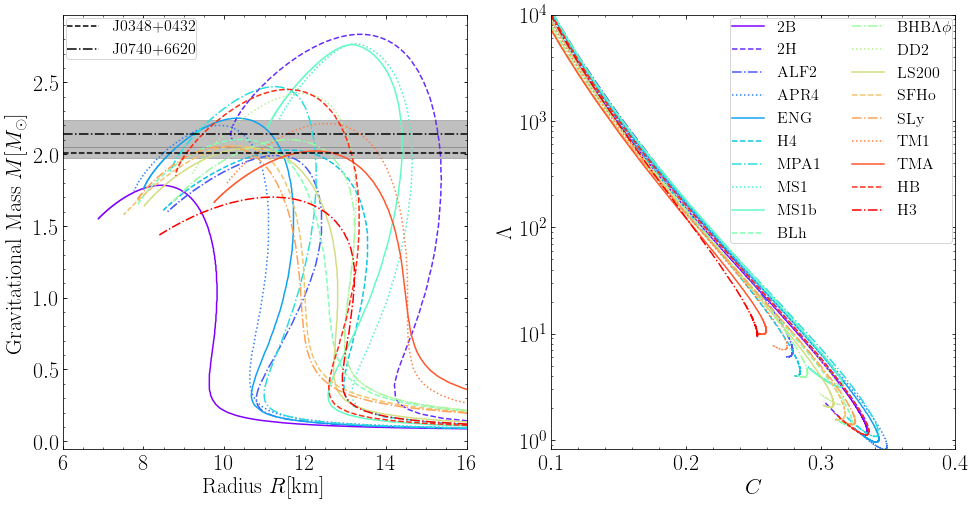

In [11]:
colors = cm.rainbow(np.linspace(0,1,len(files)))

fig, axes = plt.subplots(1, 2, figsize=(16.,8.))
fig.subplots_adjust(wspace = 0.21)
# labels = labels[0:5]
for i, f in enumerate(files):
    rhoc, M, Mb, R, C, kl, lam = np.genfromtxt(f, unpack = True, usecols = (0,1,2,3,4,5,6), skip_header=1)
    
    if labels[i].__contains__('BHB'):
        labels[i] = r'BHB$\Lambda\phi$'
    if i%4 == 0:
        ls = '-'
    elif i%4 == 1:
        ls = '--'
    elif i%4 == 2:
        ls = '-.'
    else:
        ls = ':'
    axes[0].plot(R*GMsun_c2/1e3, M, c=colors[i], ls = ls)
    
    axes[1].semilogy(C, lam, label = labels[i], c=colors[i], ls=ls)

axes[0].axhline(y = 2.01, color = 'k', ls = '--', label= 'J0348+0432')
axes[0].fill_between([6,16],y1 = 2.01-0.04, y2 = 2.01+0.04, color = 'grey', alpha = 0.5)
axes[0].axhline(y = 2.14, color = 'k', ls = '-.', label = 'J0740+6620')
axes[0].fill_between([6,16],y1 = 2.14-0.09, y2 = 2.14+0.1, color = 'grey', alpha = 0.5)
axes[0].set_ylabel(r'Gravitational Mass $M[M_\odot]$')
axes[0].set_xlabel(r'Radius $R[{\rm km}]$')
axes[0].set_xticks(np.arange(5,11,0.5), minor=True)
axes[0].set_xlim(6,16)
axes[0].legend(loc = 'best', fontsize = 16)
#axes[0].set_ylim(1.,3.)
axes[0].tick_params(axis='both', which='both', labelleft=True, labelright=False, tick1On=True, tick2On=True, direction='in')
axes[0].minorticks_on()
axes[1].set_ylabel(r'$\Lambda$')
axes[1].set_xlabel(r'$C$')
axes[1].set_xlim(0.1,0.4)
axes[1].set_ylim(0,1e4)
#axes[1].set_yticks(np.arange(0,1600,100), minor=True)
#axes[1].set_xlim(0.09,0.2)
#axes[1].set_ylim(0.,10000.)
axes[1].minorticks_on()
axes[1].tick_params(axis='both', which='both', labelleft=True, labelright=False, tick1On=True, tick2On=True, direction='in')
#ax1.legend(loc = 'best', fontsize = 15)
axes[1].legend(loc = 'best', fontsize = 16, ncol = 2)
plt.savefig('MR_LamC_diagram.png')
